In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data = pd.read_csv("motors.csv")

In [3]:
data.head()

,Unnamed: 0,CURRENT (A) mean,CURRENT (A) std,CURRENT (A) max,CURRENT (A) rms,CURRENT (A) peak_to_peak,CURRENT (A) skew,CURRENT (A) kurtosis,CURRENT (A) crest_factor,ROTO (RPM) mean,...,CURRENT (A) Spectrum Area,CURRENT (A) Amp @ 1x RPM,CURRENT (A) Amp @ 2x RPM,CURRENT (A) Amp @ 3x RPM,ROTO (RPM) Frequency Center,ROTO (RPM) Spectrum Area,ROTO (RPM) Amp @ 1x RPM,ROTO (RPM) Amp @ 2x RPM,ROTO (RPM) Amp @ 3x RPM,Class
0,0,4.282267,0.959033,7.273976,4.388340,5.975432,0.058508,-0.379241,1.698627,22969.800642,...,1.292779e+06,64.514344,192.412822,979.120670,9348.489312,1.890388e+09,77752.666640,166198.451004,166198.451004,Elec_Damage
1,1,4.240193,0.963069,7.298392,4.348185,6.110936,0.058439,-0.365732,1.721241,22970.527609,...,1.305889e+06,57.439401,361.476734,274.897913,9393.279908,1.894902e+09,29582.295619,177100.682568,177100.682568,Elec_Damage
2,2,4.239738,0.966752,7.439992,4.348559,6.341648,0.047411,-0.363346,1.754823,22972.986171,...,1.315128e+06,843.010592,275.595755,105.248133,9123.764068,1.849158e+09,83713.253702,23324.721909,23324.721909,Elec_Damage
3,3,4.242071,0.969813,7.300832,4.351515,6.226904,0.034595,-0.381739,1.721054,22974.758331,...,1.304290e+06,632.362919,216.780924,105.926822,9330.988497,1.882492e+09,129477.293171,89113.839562,89113.839562,Elec_Damage
4,4,4.245892,0.961609,7.288624,4.353420,6.010832,0.047197,-0.397627,1.716630,22975.544481,...,1.319682e+06,105.244076,303.625465,77.780279,9295.572445,1.878352e+09,94966.452288,14365.635080,14365.635080,Elec_Damage


In [4]:
data.duplicated().sum()

np.int64(0)

No duplications !!

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    184 non-null    int64  
 1   CURRENT (A) mean              184 non-null    float64
 2   CURRENT (A) std               184 non-null    float64
 3   CURRENT (A) max               184 non-null    float64
 4   CURRENT (A) rms               184 non-null    float64
 5   CURRENT (A) peak_to_peak      184 non-null    float64
 6   CURRENT (A) skew              184 non-null    float64
 7   CURRENT (A) kurtosis          184 non-null    float64
 8   CURRENT (A) crest_factor      184 non-null    float64
 9   ROTO (RPM) mean               184 non-null    float64
 10  ROTO (RPM) std                184 non-null    float64
 11  ROTO (RPM) max                184 non-null    float64
 12  ROTO (RPM) rms                184 non-null    float64
 13  ROTO (RPM) peak_

So the data has no null values

In [6]:
data['Class'].value_counts()

Class
Elec_Damage         46
Healthy             46
Mech_Elec_Damage    46
Mech_Damage         46
Name: count, dtype: int64

Class is the target variable
and perfectly balanced (no bias)
And we need to do multiclass classification since there are 4 types of classes :- Elec_Damage, Healthy, Mech_Damage and Mech_Elec_Damage

In [7]:
data.isnull().sum()

Unnamed: 0                      0
CURRENT (A) mean                0
CURRENT (A) std                 0
CURRENT (A) max                 0
CURRENT (A) rms                 0
CURRENT (A) peak_to_peak        0
CURRENT (A) skew                0
CURRENT (A) kurtosis            0
CURRENT (A) crest_factor        0
ROTO (RPM) mean                 0
ROTO (RPM) std                  0
ROTO (RPM) max                  0
ROTO (RPM) rms                  0
ROTO (RPM) peak_to_peak         0
ROTO (RPM) skew                 0
ROTO (RPM) kurtosis             0
ROTO (RPM) crest_factor         0
CURRENT (A) Frequency Center    0
CURRENT (A) Spectrum Area       0
CURRENT (A) Amp @ 1x RPM        0
CURRENT (A) Amp @ 2x RPM        0
CURRENT (A) Amp @ 3x RPM        0
ROTO (RPM) Frequency Center     0
ROTO (RPM) Spectrum Area        0
ROTO (RPM) Amp @ 1x RPM         0
ROTO (RPM) Amp @ 2x RPM         0
ROTO (RPM) Amp @ 3x RPM         0
Class                           0
dtype: int64

In [8]:
data.describe()

,Unnamed: 0,CURRENT (A) mean,CURRENT (A) std,CURRENT (A) max,CURRENT (A) rms,CURRENT (A) peak_to_peak,CURRENT (A) skew,CURRENT (A) kurtosis,CURRENT (A) crest_factor,ROTO (RPM) mean,...,CURRENT (A) Frequency Center,CURRENT (A) Spectrum Area,CURRENT (A) Amp @ 1x RPM,CURRENT (A) Amp @ 2x RPM,CURRENT (A) Amp @ 3x RPM,ROTO (RPM) Frequency Center,ROTO (RPM) Spectrum Area,ROTO (RPM) Amp @ 1x RPM,ROTO (RPM) Amp @ 2x RPM,ROTO (RPM) Amp @ 3x RPM
count,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,...,184.000000,1.840000e+02,184.000000,184.000000,184.000000,184.000000,1.840000e+02,184.000000,184.000000,184.000000
mean,91.500000,3.695297,0.974948,6.862613,3.824863,6.311503,0.033544,-0.355977,1.879285,22299.477790,...,3250.875416,1.335272e+06,839.349466,738.265920,687.582084,9575.092096,1.880391e+09,128078.418309,101767.372540,101767.372540
std,53.260367,0.564023,0.028160,0.529765,0.543072,0.288150,0.028448,0.036570,0.152590,574.564806,...,450.341732,1.026172e+05,625.576209,619.812196,542.484195,168.953843,2.469224e+07,82854.351369,57486.255850,57486.255850
min,0.000000,3.042636,0.888497,6.116728,3.200628,5.708096,-0.041387,-0.420982,1.647754,21623.944117,...,2698.043127,1.012856e+06,57.439401,24.967852,17.698082,9123.764068,1.814355e+09,9137.747792,6802.709633,6802.709633
25%,45.750000,3.156146,0.960363,6.371862,3.306826,6.082244,0.012171,-0.386912,1.729991,21736.942201,...,2801.806128,1.292558e+06,428.016582,281.279153,299.505544,9457.814692,1.864742e+09,71635.835042,64477.376426,64477.376426
50%,91.500000,3.582062,0.979152,6.858320,3.713812,6.290376,0.033106,-0.360477,1.877427,22242.577133,...,3281.060834,1.350553e+06,666.659345,493.083058,522.761749,9575.758177,1.878860e+09,113363.387300,94006.569462,94006.569462
75%,137.250000,4.218445,0.995601,7.295644,4.316892,6.507672,0.051799,-0.327337,2.020353,22864.042052,...,3692.671836,1.413324e+06,1122.418141,1074.373009,934.907180,9731.833833,1.900344e+09,175914.987767,124699.805221,124699.805221
max,183.000000,4.900168,1.026084,8.162664,5.002649,7.183944,0.103741,-0.265615,2.157569,22996.800559,...,3862.771310,1.479207e+06,3837.046853,3276.884213,2757.528024,9839.695848,1.931495e+09,753453.771279,334237.763675,334237.763675


In [9]:
data = data.drop(columns=['Unnamed: 0'])

In [10]:
data.head()

,CURRENT (A) mean,CURRENT (A) std,CURRENT (A) max,CURRENT (A) rms,CURRENT (A) peak_to_peak,CURRENT (A) skew,CURRENT (A) kurtosis,CURRENT (A) crest_factor,ROTO (RPM) mean,ROTO (RPM) std,...,CURRENT (A) Spectrum Area,CURRENT (A) Amp @ 1x RPM,CURRENT (A) Amp @ 2x RPM,CURRENT (A) Amp @ 3x RPM,ROTO (RPM) Frequency Center,ROTO (RPM) Spectrum Area,ROTO (RPM) Amp @ 1x RPM,ROTO (RPM) Amp @ 2x RPM,ROTO (RPM) Amp @ 3x RPM,Class
0,4.282267,0.959033,7.273976,4.388340,5.975432,0.058508,-0.379241,1.698627,22969.800642,518.422127,...,1.292779e+06,64.514344,192.412822,979.120670,9348.489312,1.890388e+09,77752.666640,166198.451004,166198.451004,Elec_Damage
1,4.240193,0.963069,7.298392,4.348185,6.110936,0.058439,-0.365732,1.721241,22970.527609,521.269101,...,1.305889e+06,57.439401,361.476734,274.897913,9393.279908,1.894902e+09,29582.295619,177100.682568,177100.682568,Elec_Damage
2,4.239738,0.966752,7.439992,4.348559,6.341648,0.047411,-0.363346,1.754823,22972.986171,522.826496,...,1.315128e+06,843.010592,275.595755,105.248133,9123.764068,1.849158e+09,83713.253702,23324.721909,23324.721909,Elec_Damage
3,4.242071,0.969813,7.300832,4.351515,6.226904,0.034595,-0.381739,1.721054,22974.758331,525.727297,...,1.304290e+06,632.362919,216.780924,105.926822,9330.988497,1.882492e+09,129477.293171,89113.839562,89113.839562,Elec_Damage
4,4.245892,0.961609,7.288624,4.353420,6.010832,0.047197,-0.397627,1.716630,22975.544481,522.741943,...,1.319682e+06,105.244076,303.625465,77.780279,9295.572445,1.878352e+09,94966.452288,14365.635080,14365.635080,Elec_Damage


Now, our target class doesnt have numerical values, so we need to encode
And it wont affect model since it might affect regression but not classification

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Class'] = le.fit_transform(data['Class'])

In [12]:
data['Class'].value_counts()

Class
0    46
1    46
3    46
2    46
Name: count, dtype: int64

so - 0 is for Elec_Damage, 1 is for Healthy, 2 is for Mech_Elec_Damage and 3 is for Mech_Damage

In [13]:
x = data.drop('Class',axis=1)
y = data['Class']

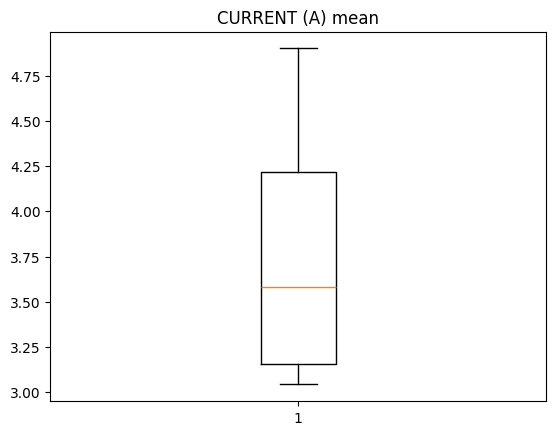

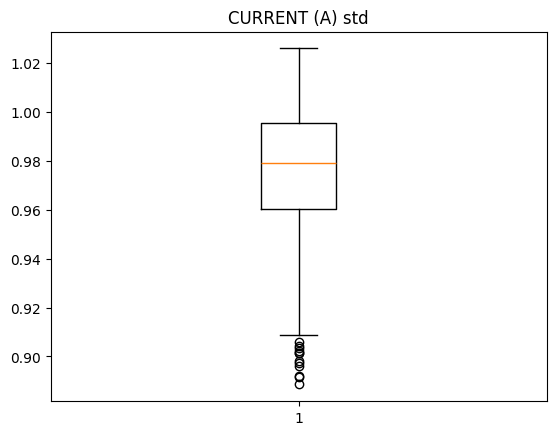

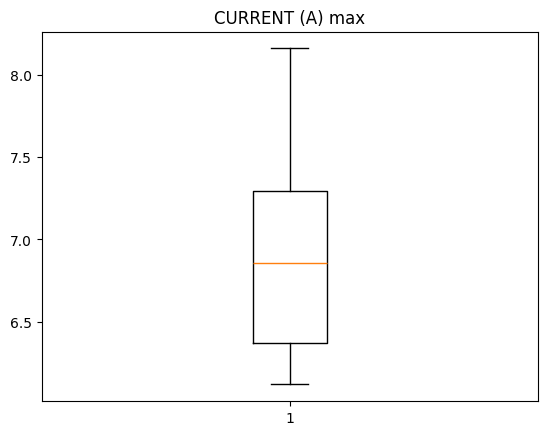

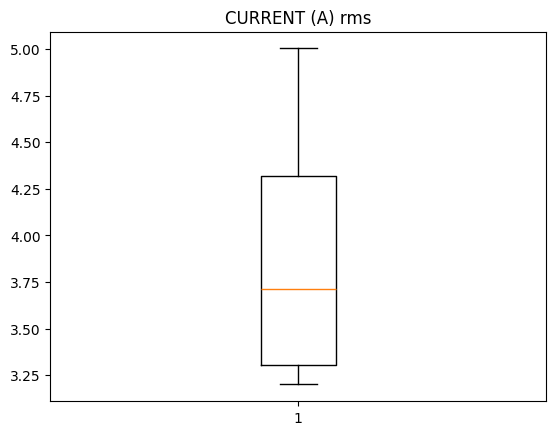

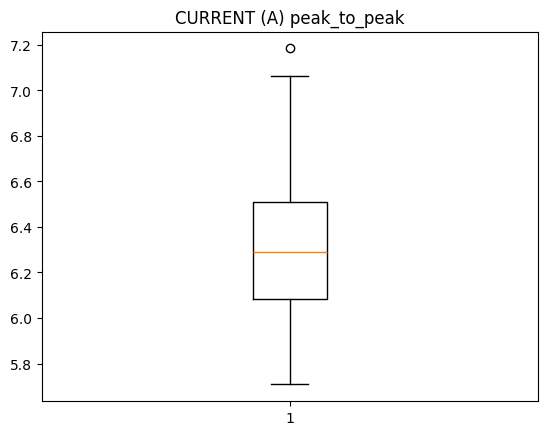

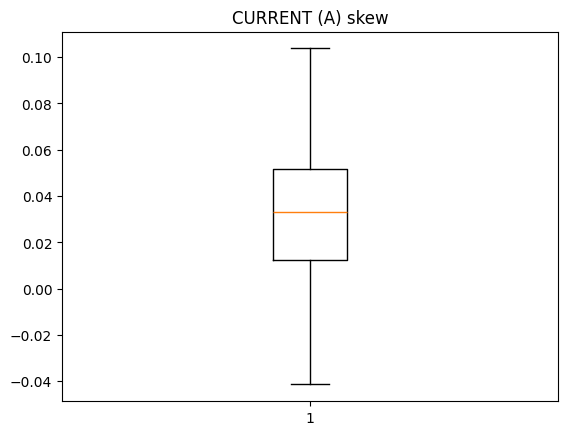

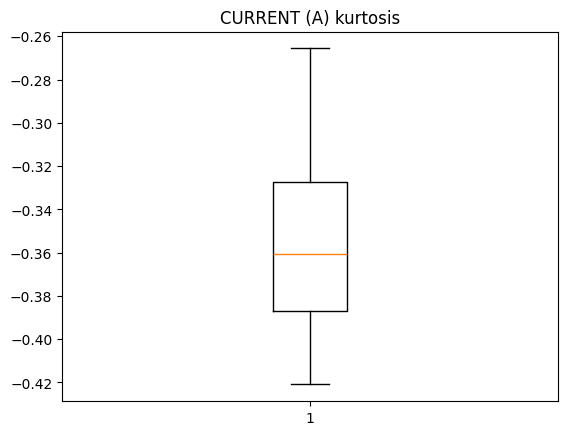

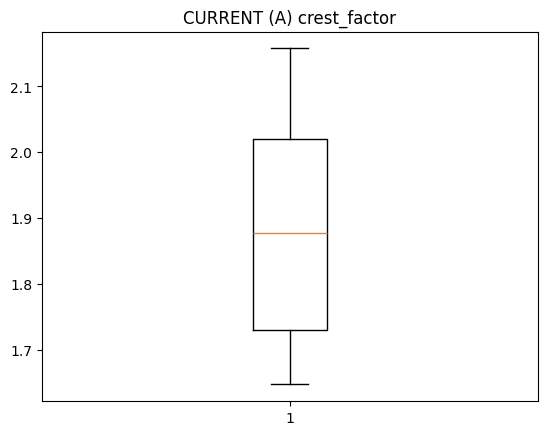

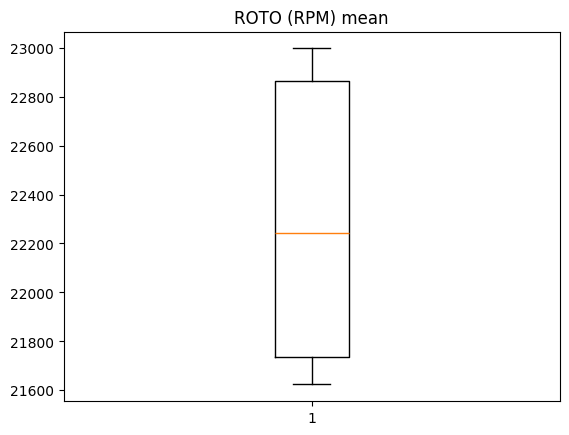

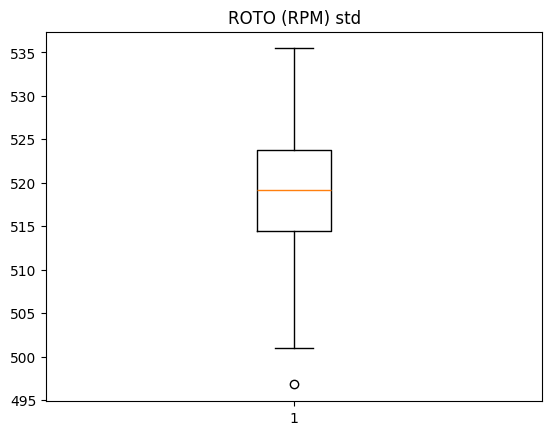

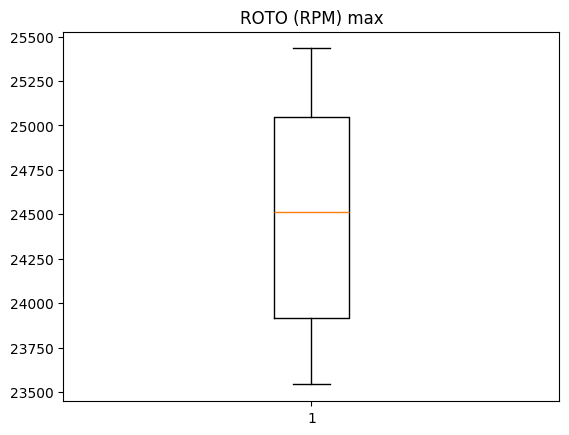

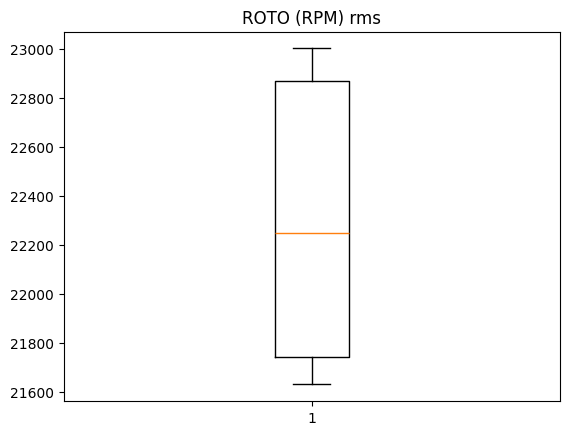

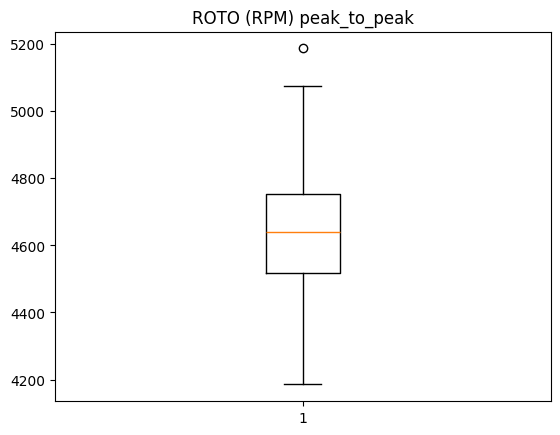

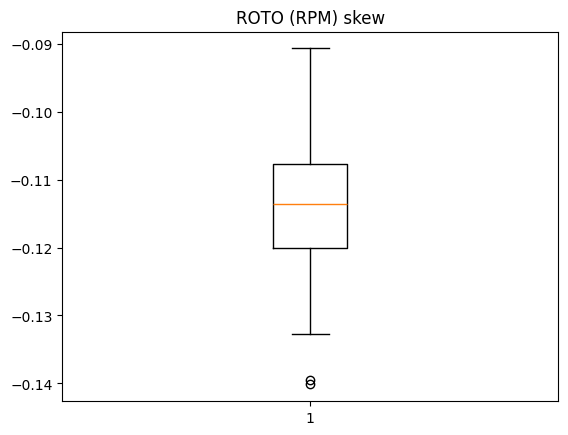

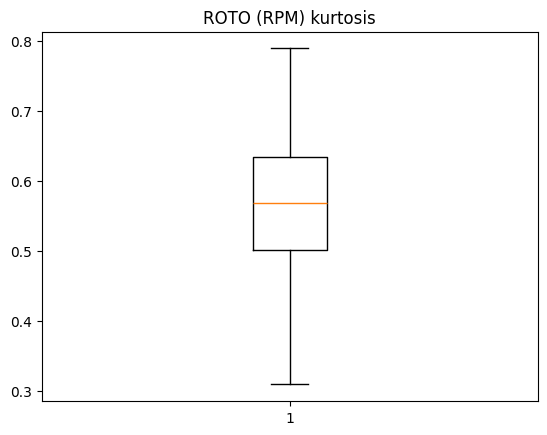

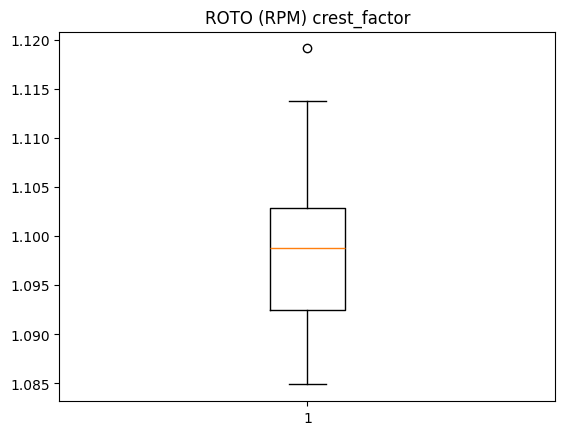

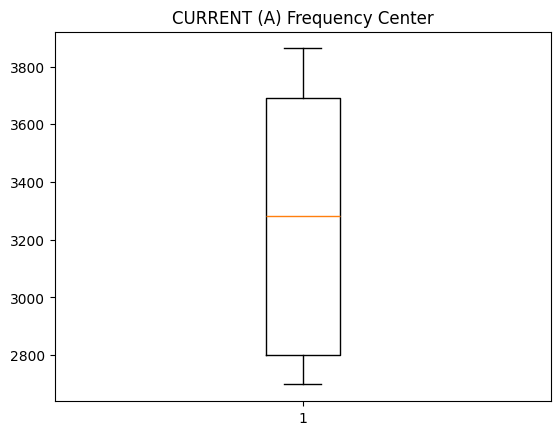

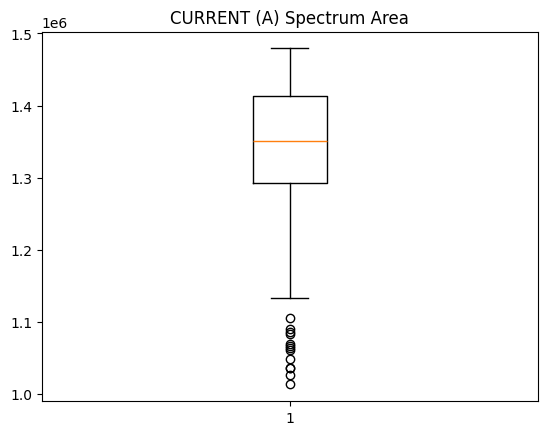

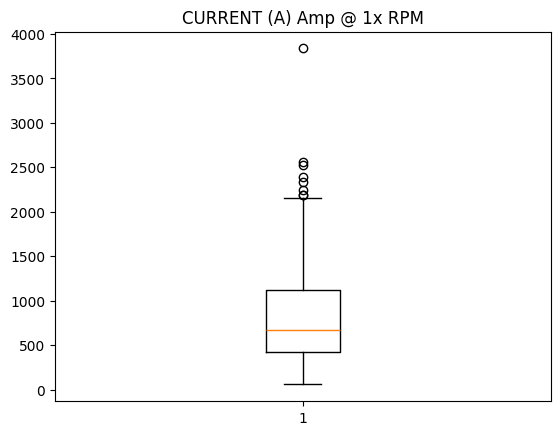

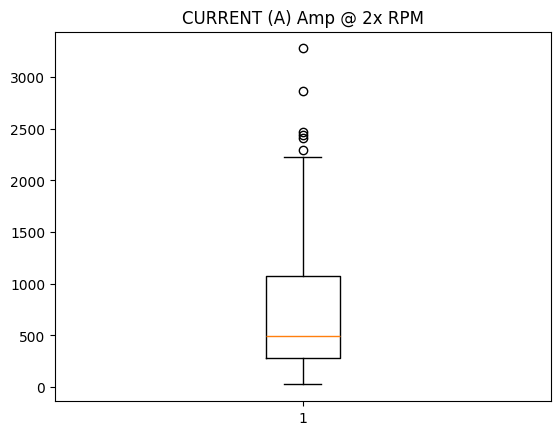

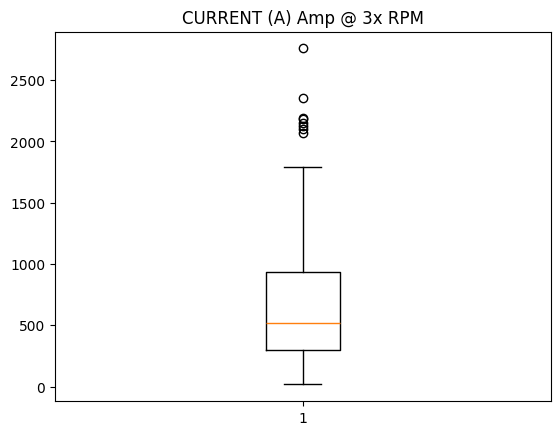

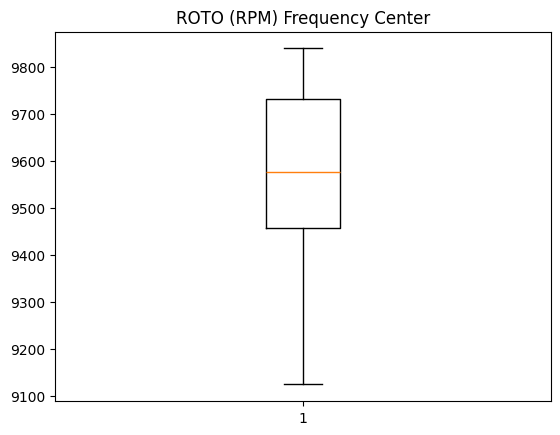

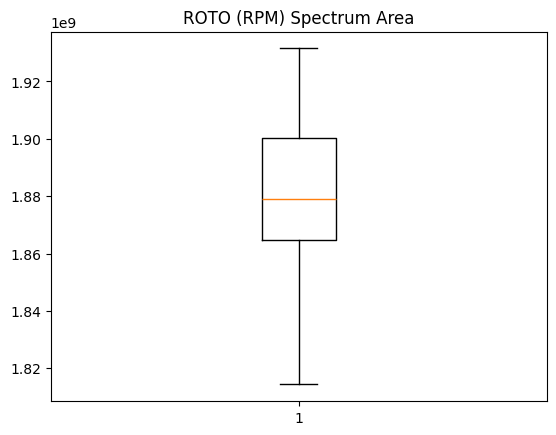

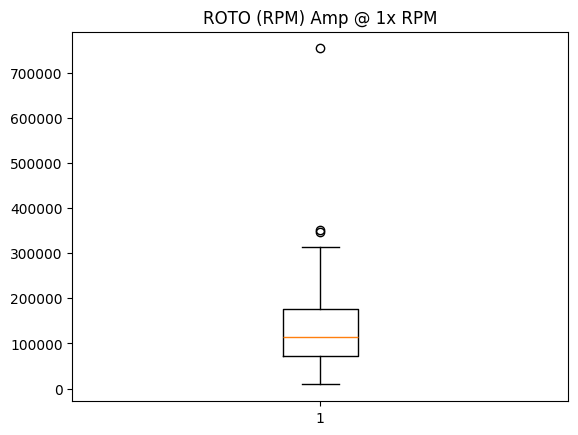

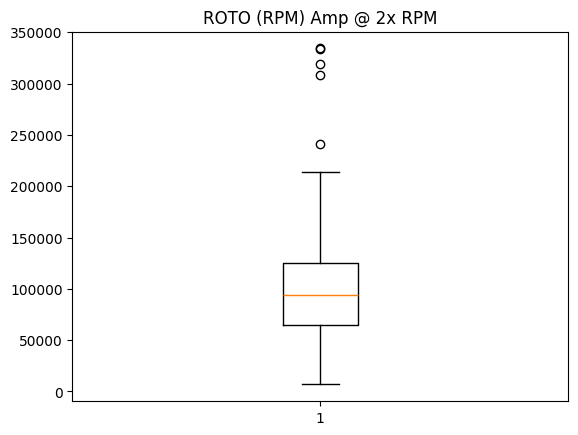

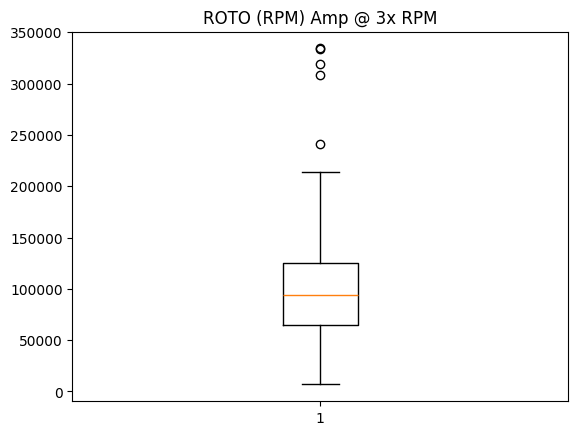

In [14]:
for col in data.columns:
    if col != 'Class':
        plt.figure()
        plt.boxplot(x[col])
        plt.title(col)
        plt.show()

We didnt remove outliers since removing them means removing faults, and we are using models like RandomForest, DecisionTrees and XGBoost that are robust to outliers and can handle them well

In [15]:
data.shape

(184, 27)

In [16]:
x.shape

(184, 26)

In [17]:
y.shape

(184,)

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
x_train.shape

(147, 26)

In [20]:
x_test.shape

(37, 26)

For models, we will be using decision tree, random forest and xgboost

<B>Decision Tree

In [21]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=3,random_state=42)
dt.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [22]:
y_pred_dt = dt.predict(x_test)

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [24]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test,y_pred_dt))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         9

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



In [25]:
print("Train Accuracy:", dt.score(x_train, y_train))
print("Test Accuracy:", dt.score(x_test, y_test))

Train Accuracy: 0.9795918367346939
Test Accuracy: 1.0


This shows there is no overfitting

<B>Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [27]:
y_pred_rf = rf.predict(x_test)

In [28]:
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         9

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



Data is highly separable, so now we check imp features

In [29]:
feature_imp = pd.Series(rf.feature_importances_,index=x.columns)
feature_imp = feature_imp.sort_values(ascending=False)
print(feature_imp.head(10))

ROTO (RPM) mean                 0.221593
ROTO (RPM) rms                  0.201399
ROTO (RPM) max                  0.072559
CURRENT (A) Frequency Center    0.069229
CURRENT (A) crest_factor        0.056092
CURRENT (A) rms                 0.053274
CURRENT (A) mean                0.051370
CURRENT (A) max                 0.046808
CURRENT (A) std                 0.034499
ROTO (RPM) Spectrum Area        0.030001
dtype: float64


So most imp features are ROTO (RPM) rms, ROTO (RPM) mean <BR>
medium imp features are CURRENT (A) Frequency Center, CURRENT (A) max <BR>
least imp features are ROTO (RPM) max, CURRENT (A) crest_factor, ROTO (RPM) skew <br>
Means, if RPM Behaviour changes, there is a fault <br>
and these faults affect current flow patterns significantly <br>
FINAL INSIGHT :- The model identified RPM-based features as the most critical indicators, suggesting that motor speed instability is a primary signature of faults. Current-based features further help distinguish between fault types, while higher-order statistical features contribute less.

In [30]:
top_features = feature_imp.head(5).index
x_top = x[top_features]

In [31]:
x_top.head()

,ROTO (RPM) mean,ROTO (RPM) rms,ROTO (RPM) max,CURRENT (A) Frequency Center,CURRENT (A) crest_factor
0,22969.800642,22975.650074,25191.88,2864.797127,1.698627
1,22970.527609,22976.441267,25330.74,2820.710573,1.721241
2,22972.986171,22978.934577,25063.71,2800.085704,1.754823
3,22974.758331,22980.772455,25367.36,2699.888592,1.721054
4,22975.544481,22981.490302,24964.52,2796.335695,1.716630


In [32]:
x_top.shape

(184, 5)

In [33]:
x.shape

(184, 26)

In [34]:
x_train_top, x_test_top, y_train, y_test = train_test_split(x_top, y, test_size=0.2, random_state=42)

In [35]:
rf_top = RandomForestClassifier(random_state=42)
rf_top.fit(x_train_top,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
y_pred_top = rf_top.predict(x_test_top)

In [37]:
print("RF Accuracy (Top Features):", accuracy_score(y_test, y_pred_top))
print(classification_report(y_test, y_pred_top))

RF Accuracy (Top Features): 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         9

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



We only need to monitor RPM stability and current behavior to detect faults

<B>XGBoost

In [38]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
xgb.fit(x_train_top,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [39]:
y_pred_xgb = xgb.predict(x_test_top)

In [40]:
print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGB Accuracy: 0.918918918918919
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        11
           1       1.00      0.78      0.88         9
           2       0.80      1.00      0.89         8
           3       0.90      1.00      0.95         9

    accuracy                           0.92        37
   macro avg       0.92      0.92      0.92        37
weighted avg       0.93      0.92      0.92        37



While tree-based ensemble methods achieved perfect accuracy, XGBoost revealed slight class overlap, indicating that the dataset, though highly separable, contains borderline cases.

In [41]:
top_features

Index(['ROTO (RPM) mean', 'ROTO (RPM) rms', 'ROTO (RPM) max',
       'CURRENT (A) Frequency Center', 'CURRENT (A) crest_factor'],
      dtype='str')

In [42]:
import joblib

In [43]:
joblib.dump(dt, 'decision-tree.pkl')

['decision-tree.pkl']

In [44]:
joblib.dump(rf, 'random_forest.pkl')

['random_forest.pkl']

In [45]:
joblib.dump(xgb, 'xgboost.pkl')

['xgboost.pkl']

In [46]:
joblib.dump(top_features,'features.pkl')

['features.pkl']

In [47]:
joblib.dump(le, 'label-encoder.pkl')

['label-encoder.pkl']

In [48]:
dt = joblib.load("decision-tree.pkl")
rf = joblib.load("random_forest.pkl")
xgb = joblib.load("xgboost.pkl")
features = joblib.load("features.pkl")
le = joblib.load("label-encoder.pkl")

In [49]:
dt

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [50]:
rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [51]:
xgb

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [52]:
features

Index(['ROTO (RPM) mean', 'ROTO (RPM) rms', 'ROTO (RPM) max',
       'CURRENT (A) Frequency Center', 'CURRENT (A) crest_factor'],
      dtype='str')

In [53]:
le

LabelEncoder()